# 📊 Evaluierung der LLM Prompting-Ansätze (Lohmann & Rauscher)

Dieses Notebook vergleicht die drei entwickelten Prompting-Ansätze über alle 60 Wundbilder:
1. **Zero-Shot**: Direkte Generierung des Ziel-Schemas aus Wundbild + Produktkatalog.
2. **Few-Shot**: In-Context Learning mit 3 Referenz-Beispielen inklusive Ground Truth.
3. **Two-Stage**: Zweistufiges Reasoning (Stufe 1: Bild-Befundung -> Stufe 2: Produktzuordnung).

Die Auswertungen sind gegliedert nach:
- **Wundbeschreibung** (10 optische/klinische Merkmale)
- **Produktempfehlungen** (4 Produktkategorien aus dem L&R-Katalog)
- **Vergleichsbasis**: Experte 1, Experte 2 und Konsens (Best-of-Both-Experts).

In [16]:
from prompt_analysis import PromptAnalysis

# Initialisierung und Laden der normalisierten Evaluierungsdaten
pa = PromptAnalysis(normalised=True)

## 1. Übersichtstabelle (F1-Score / Accuracy in %)
Gegenüberstellung der gemittelten Scores über beide Experten für Wundbeschreibung, Produktempfehlungen und Gesamtergebnis.

In [17]:
pa.show_summary_table()

,Zero-Shot,Few-Shot,Two-Stage
Kategorie,,,
Wundtyp,40.8%,38.8%,44.2%
Lokalisation,72.5%,75.0%,70.8%
Wundstadium,55.5%,55.7%,55.7%
Wundgrund,32.7%,40.0%,35.9%
Wundrand,48.9%,48.3%,47.4%
Wundumgebung,45.1%,41.5%,39.5%
Exsudat,67.1%,66.6%,67.7%
Debridement notwendig,85.8%,88.8%,87.5%
Debridement Methode,37.1%,38.9%,41.2%


## 2. Grafische Gegenüberstellung (Wundbeschreibung vs. Produktempfehlungen)
Visualisierung der aggregierten Werte für die 10 Wundbeschreibungs-Kategorien (links) und die 4 Produkt-Kategorien inkl. Gesamtdurchschnitt (rechts).

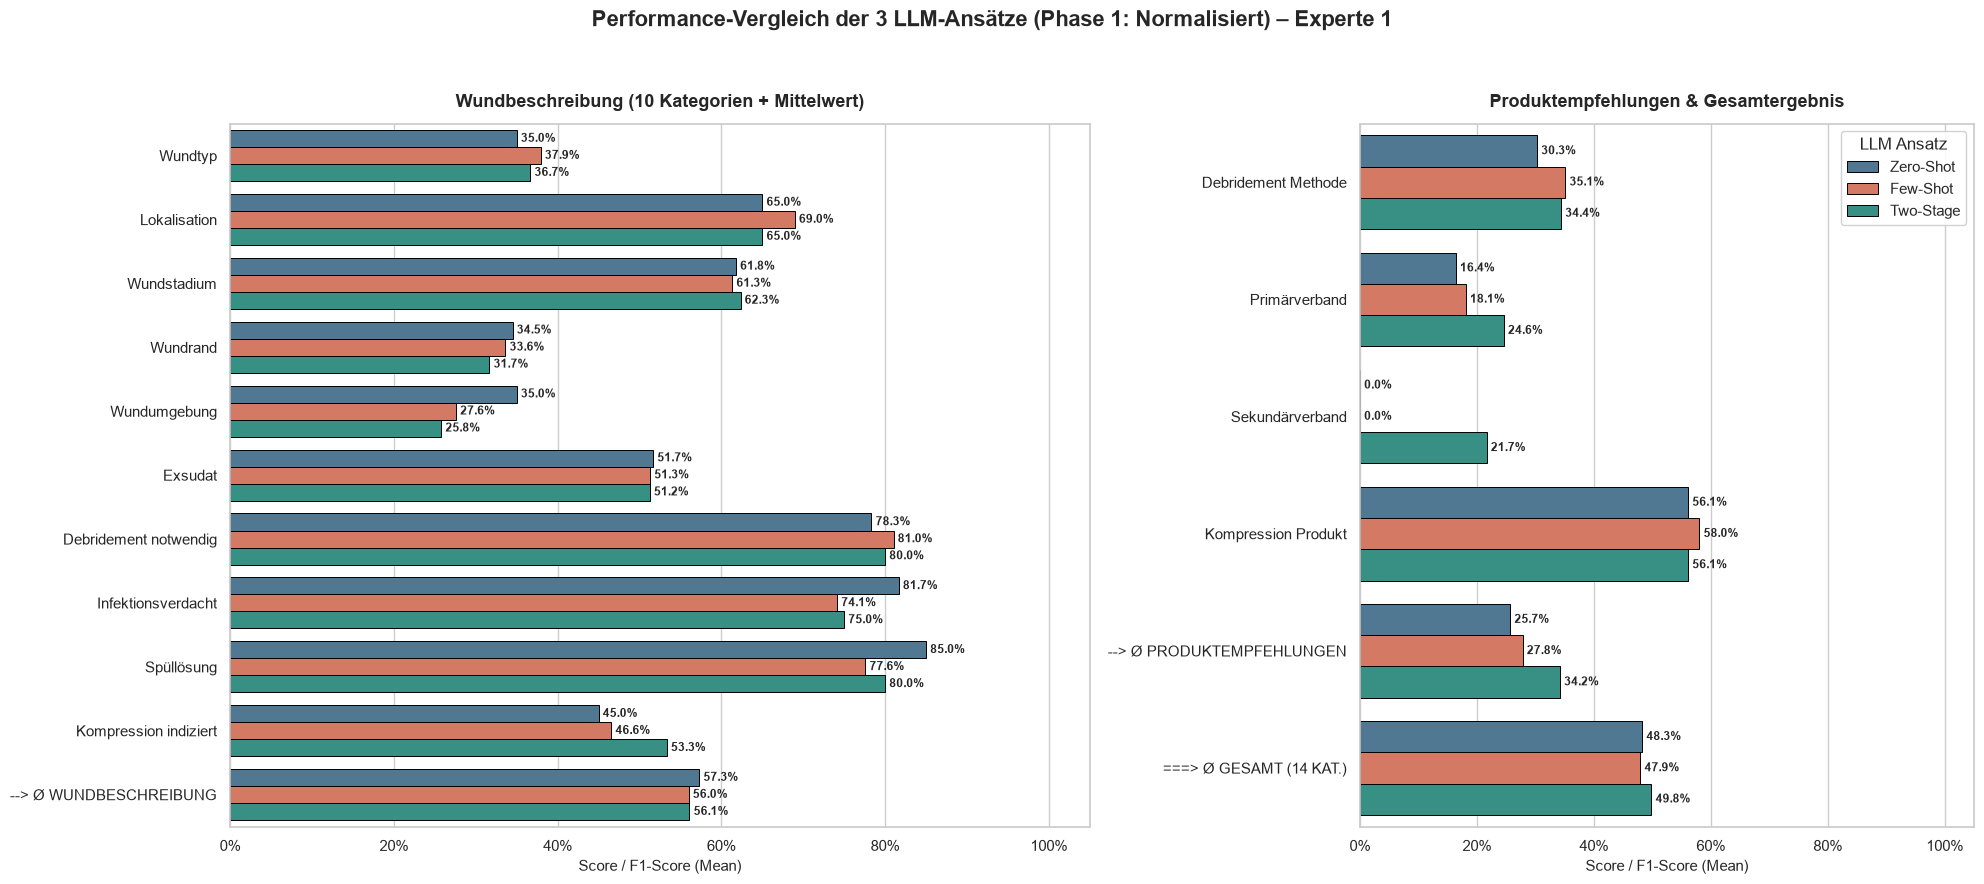

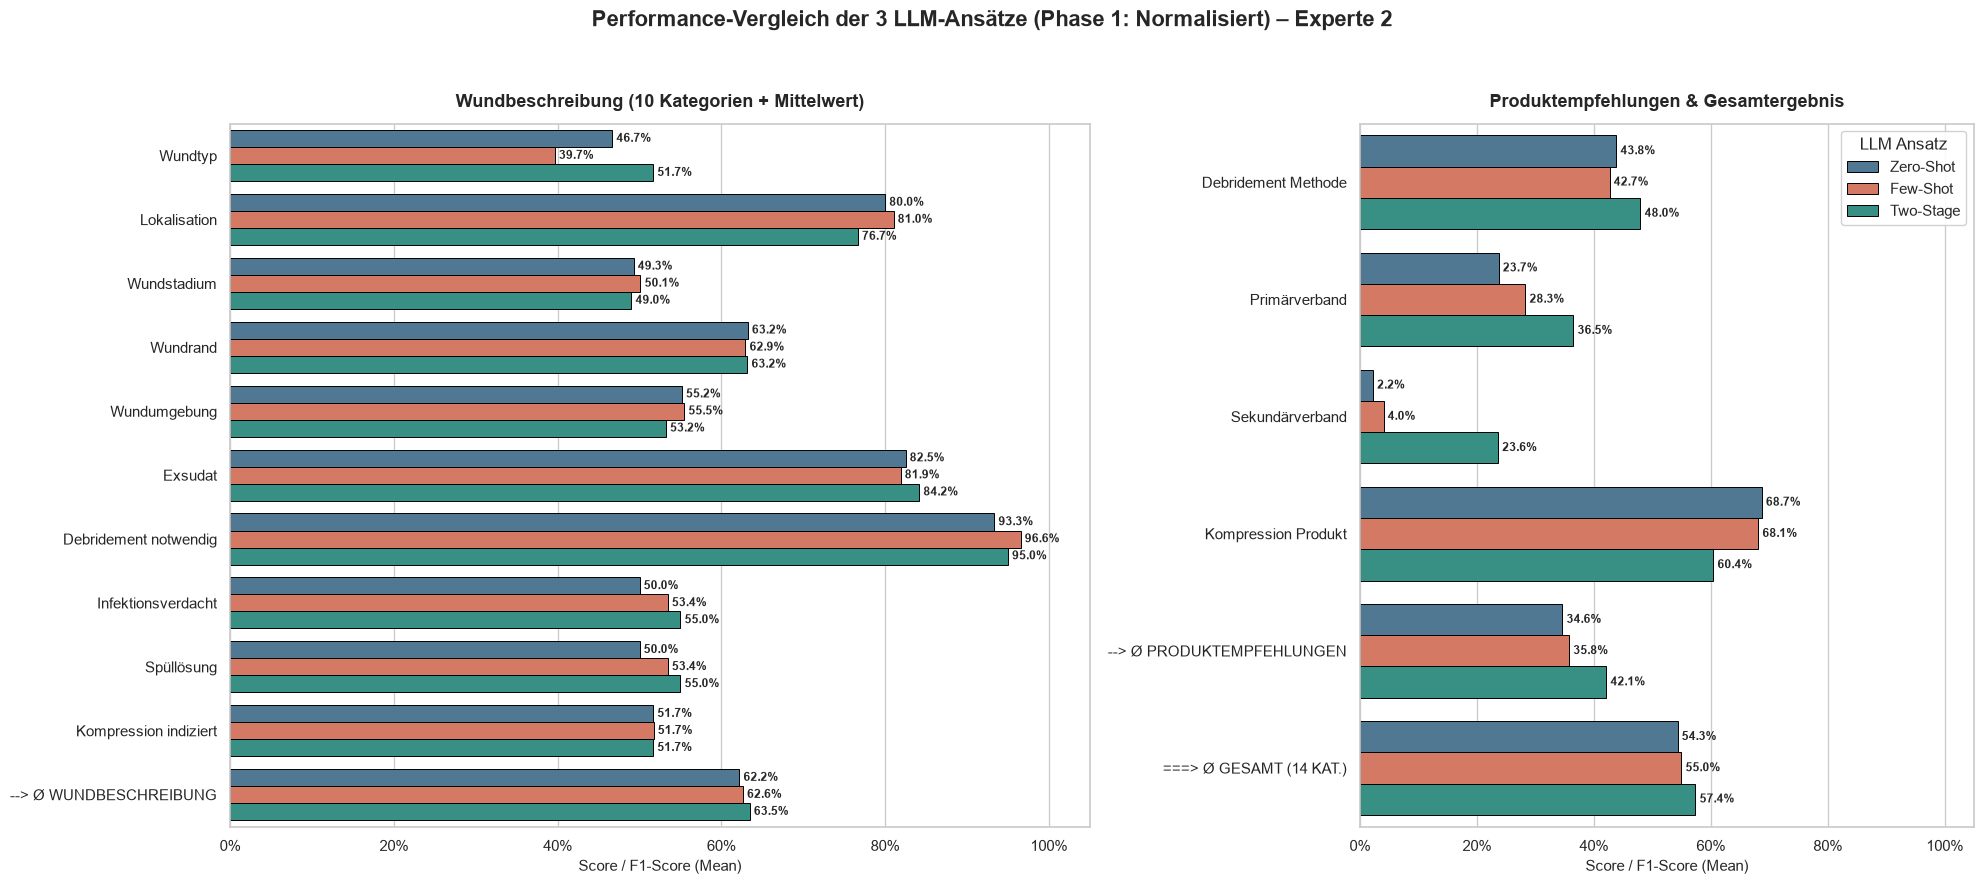

In [18]:
# Performance-Übersicht getrennt nach Experte 1 und Experte 2
pa.plot_overview_groups_expert(1)
pa.plot_overview_groups_expert(2)

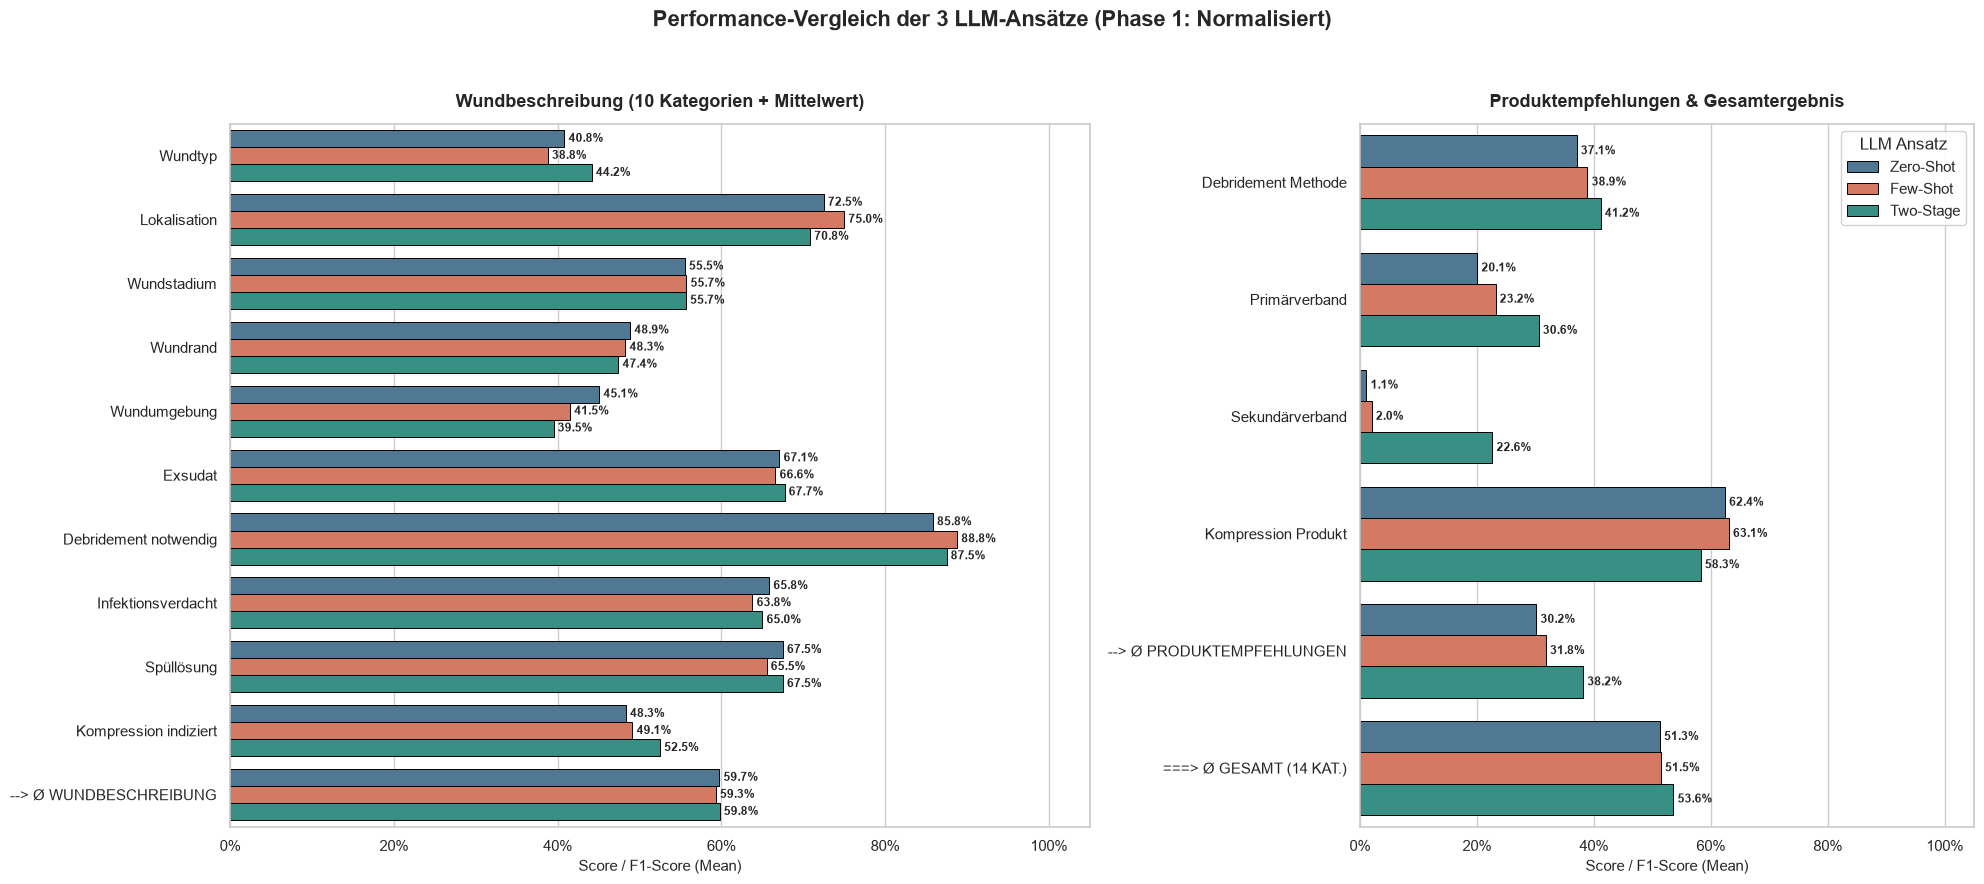

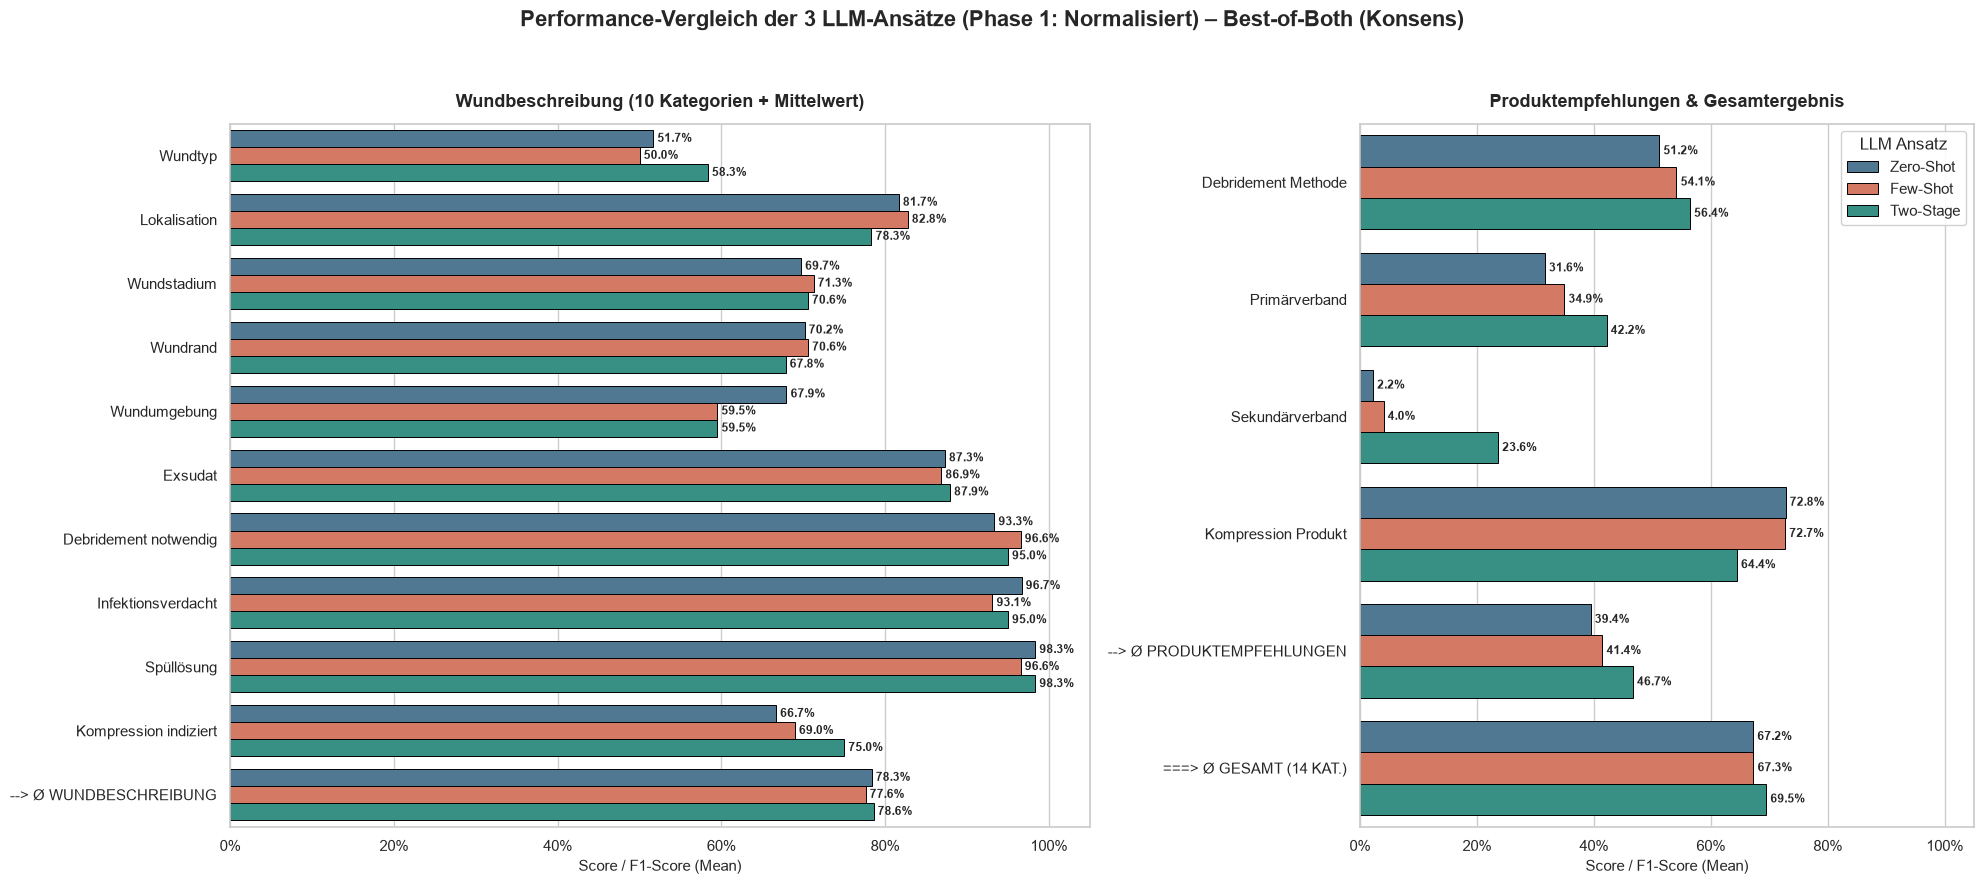

In [19]:
pa.plot_overview_groups()
# Performance-Übersicht der 3 Prompt-Ansätze mit Best-of-Both (Konsens)
pa.plot_overview_groups_consensus()

## 3. Detail-Auswertung: Vergleich mit Experte 1
F1-Scores / Exact Match über alle 15 Einzelkategorien bezogen auf die Ground Truth von **Experte 1**.

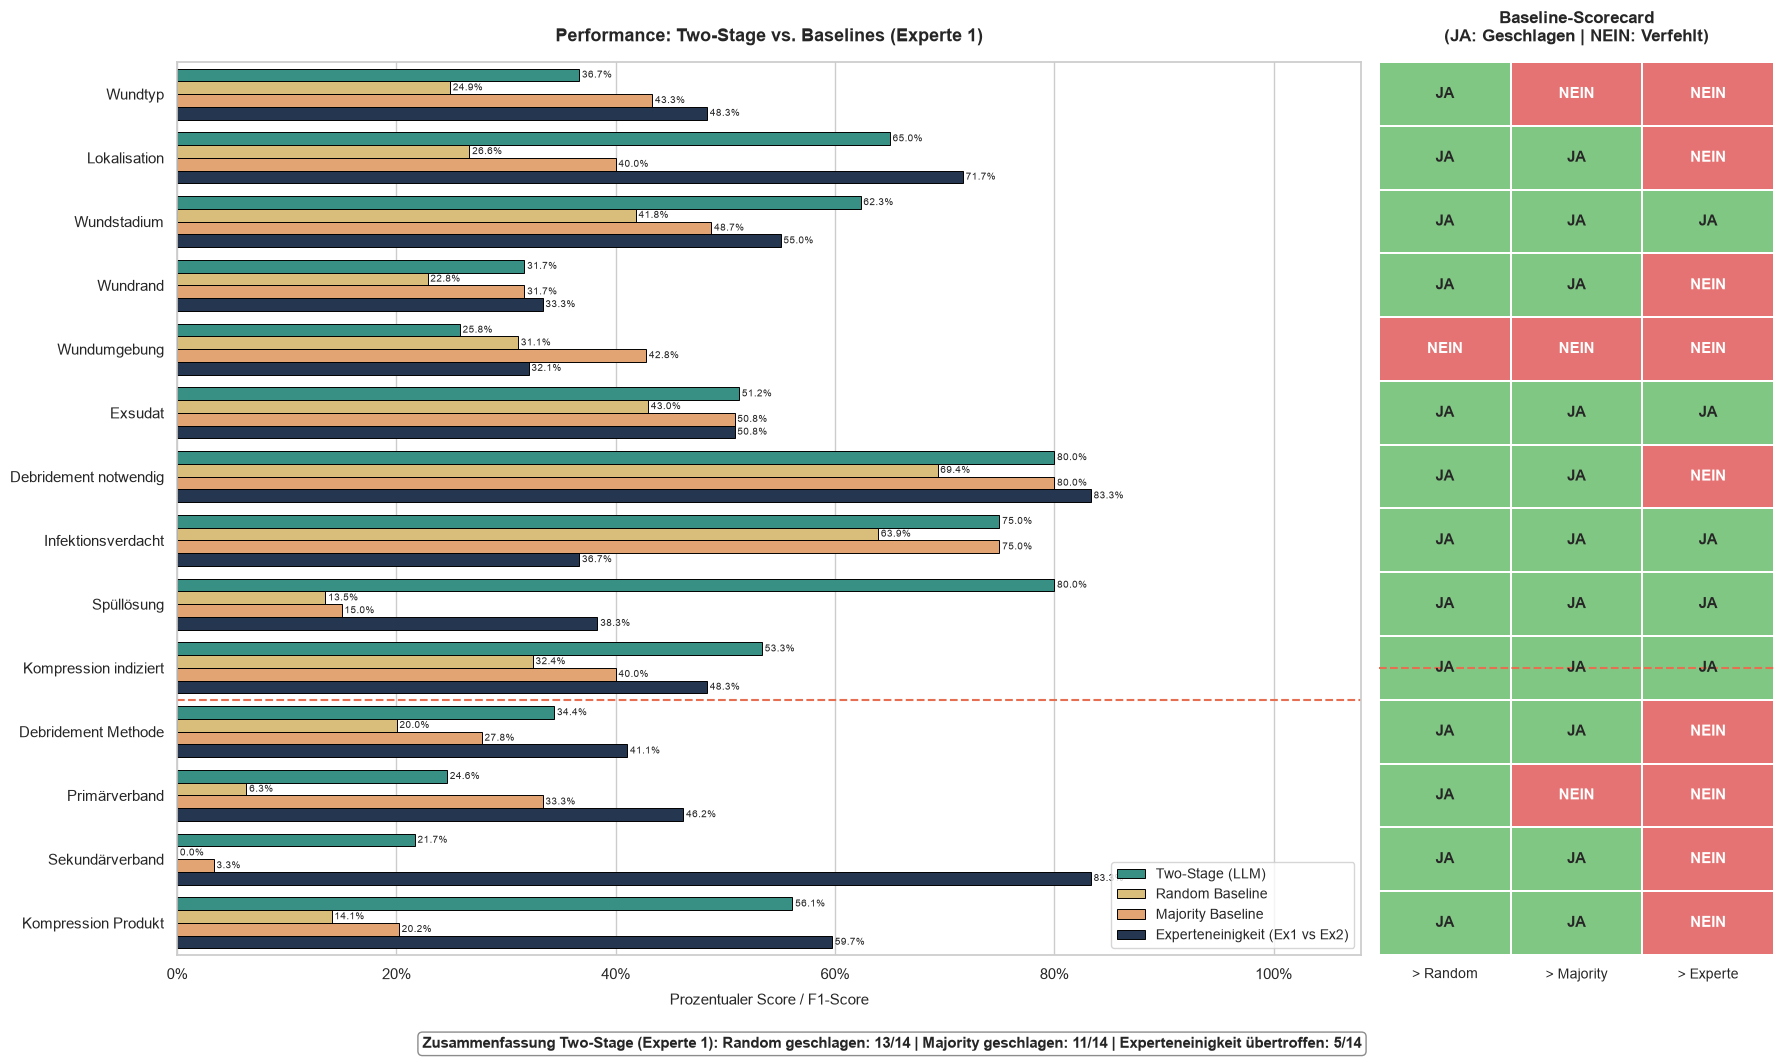

In [20]:
pa.plot_expert1()

## 4. Detail-Auswertung: Vergleich mit Experte 2
F1-Scores / Exact Match über alle 15 Einzelkategorien bezogen auf die Ground Truth von **Experte 2**.

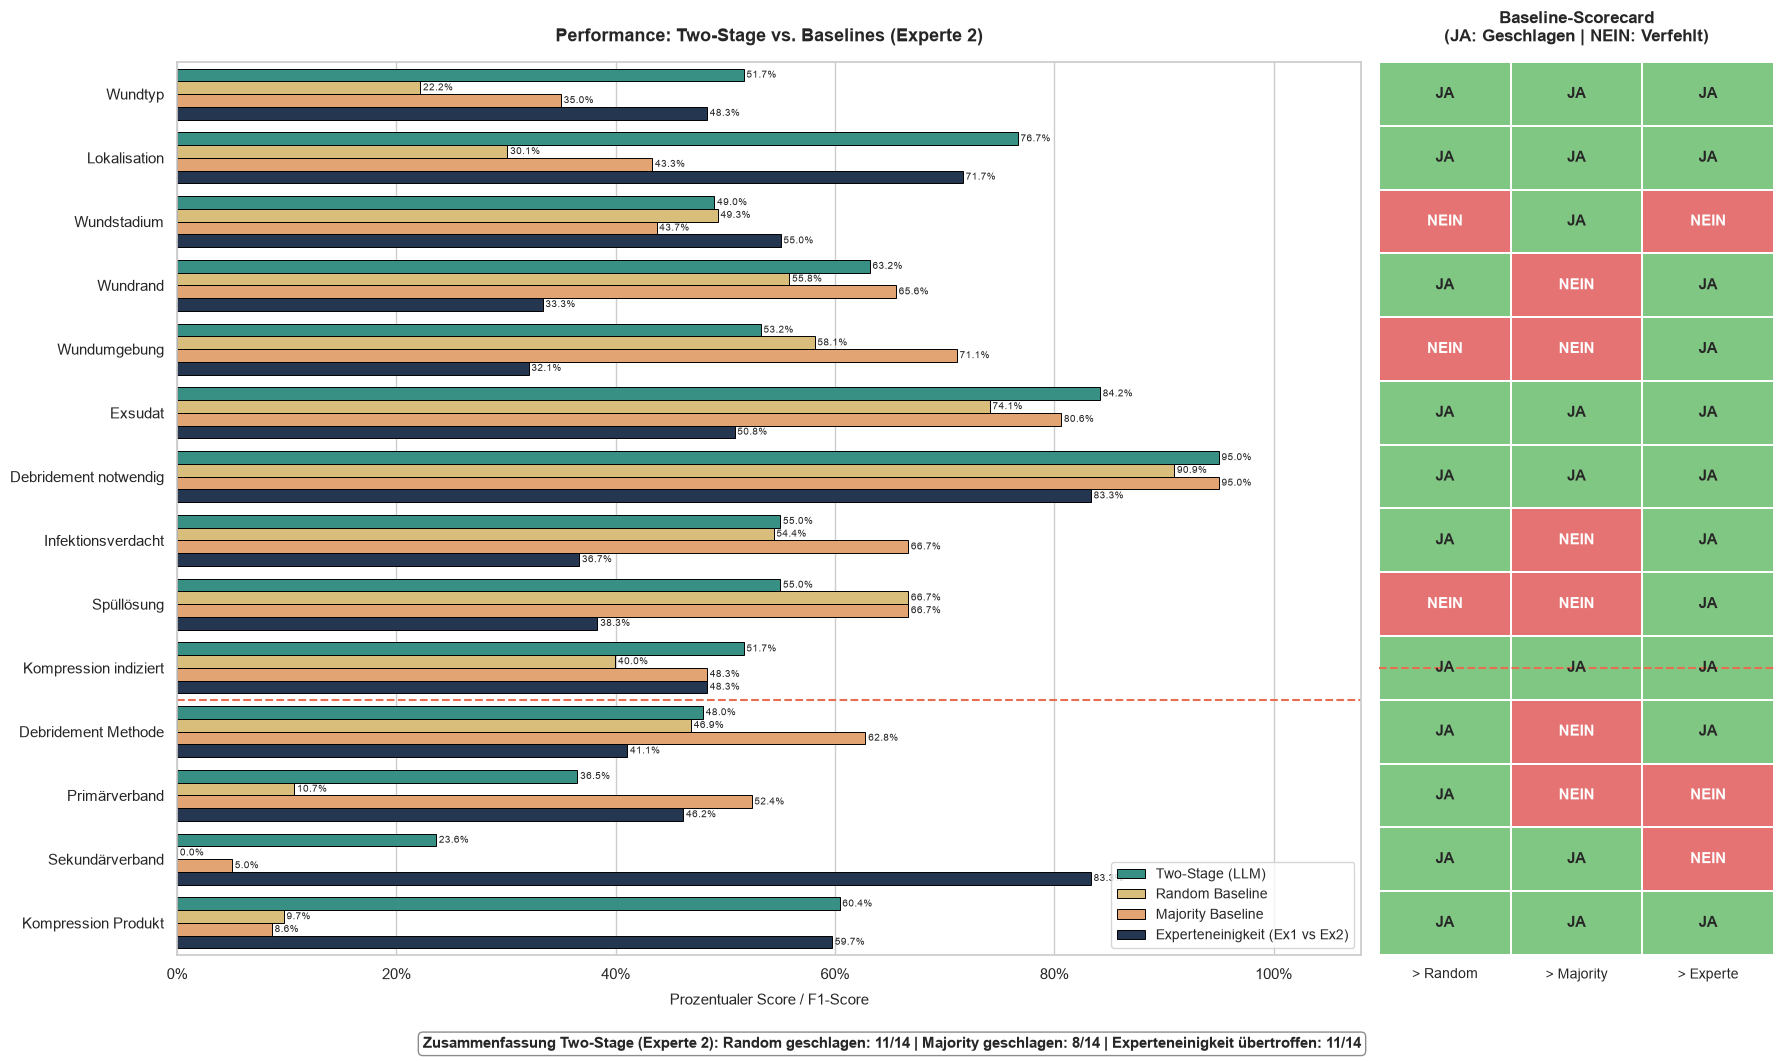

In [21]:
pa.plot_expert2()

## 5. Detail-Auswertung: Vergleich mit dem Konsens-Score
F1-Scores / Exact Match über alle 15 Einzelkategorien bezogen auf den **Konsens (Best-of-Both-Experts)**.

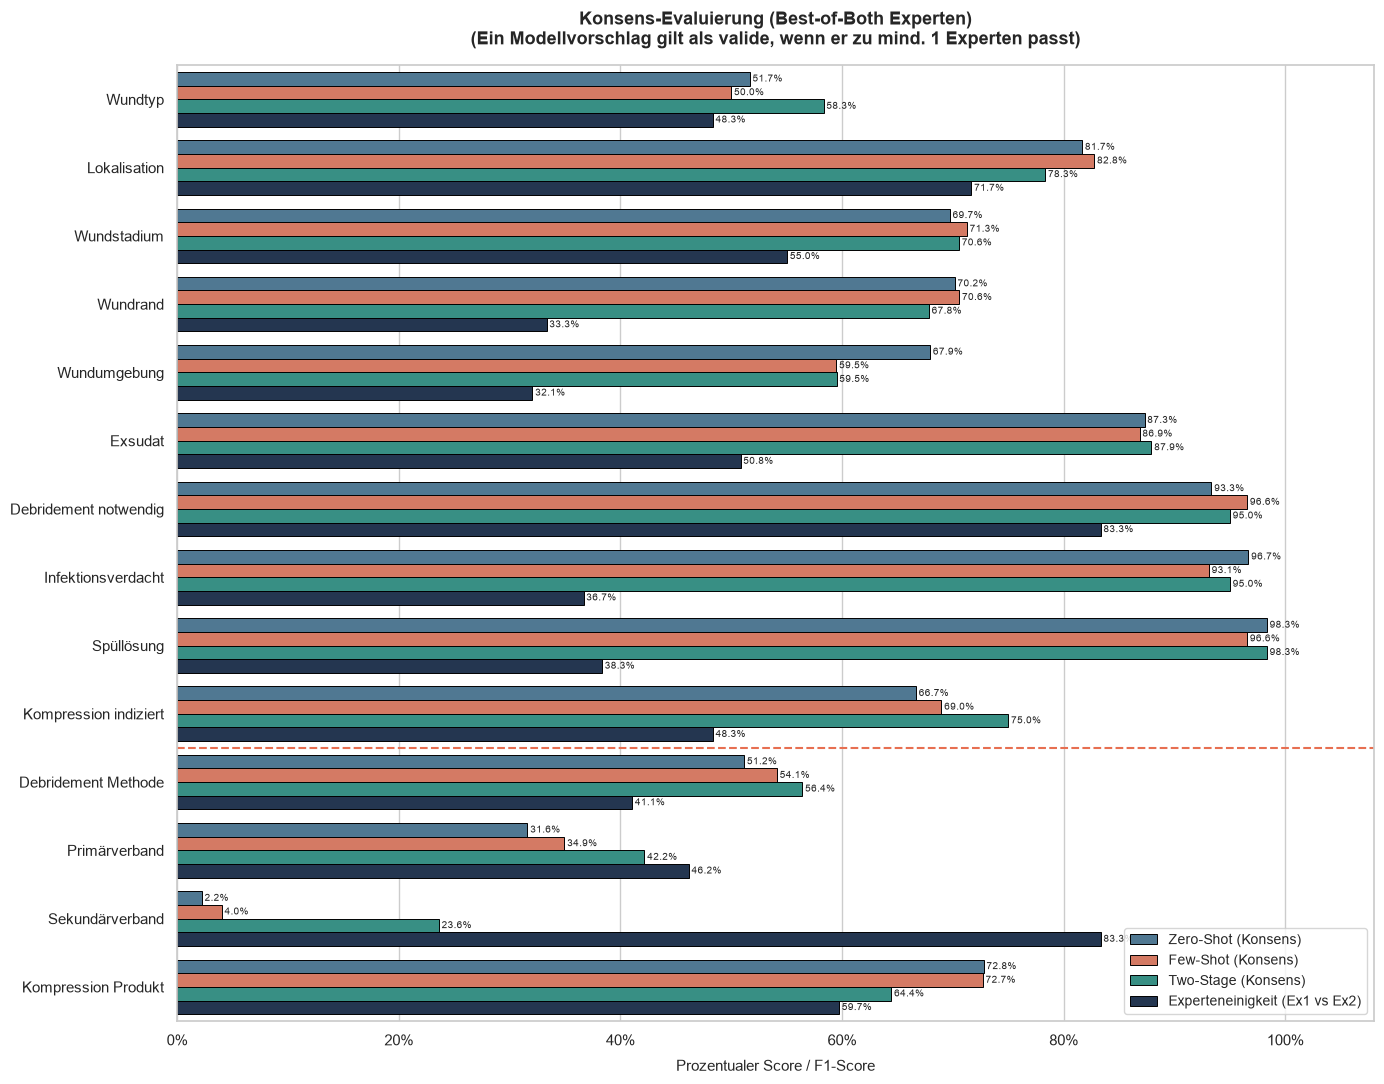

In [22]:
pa.plot_consensus()

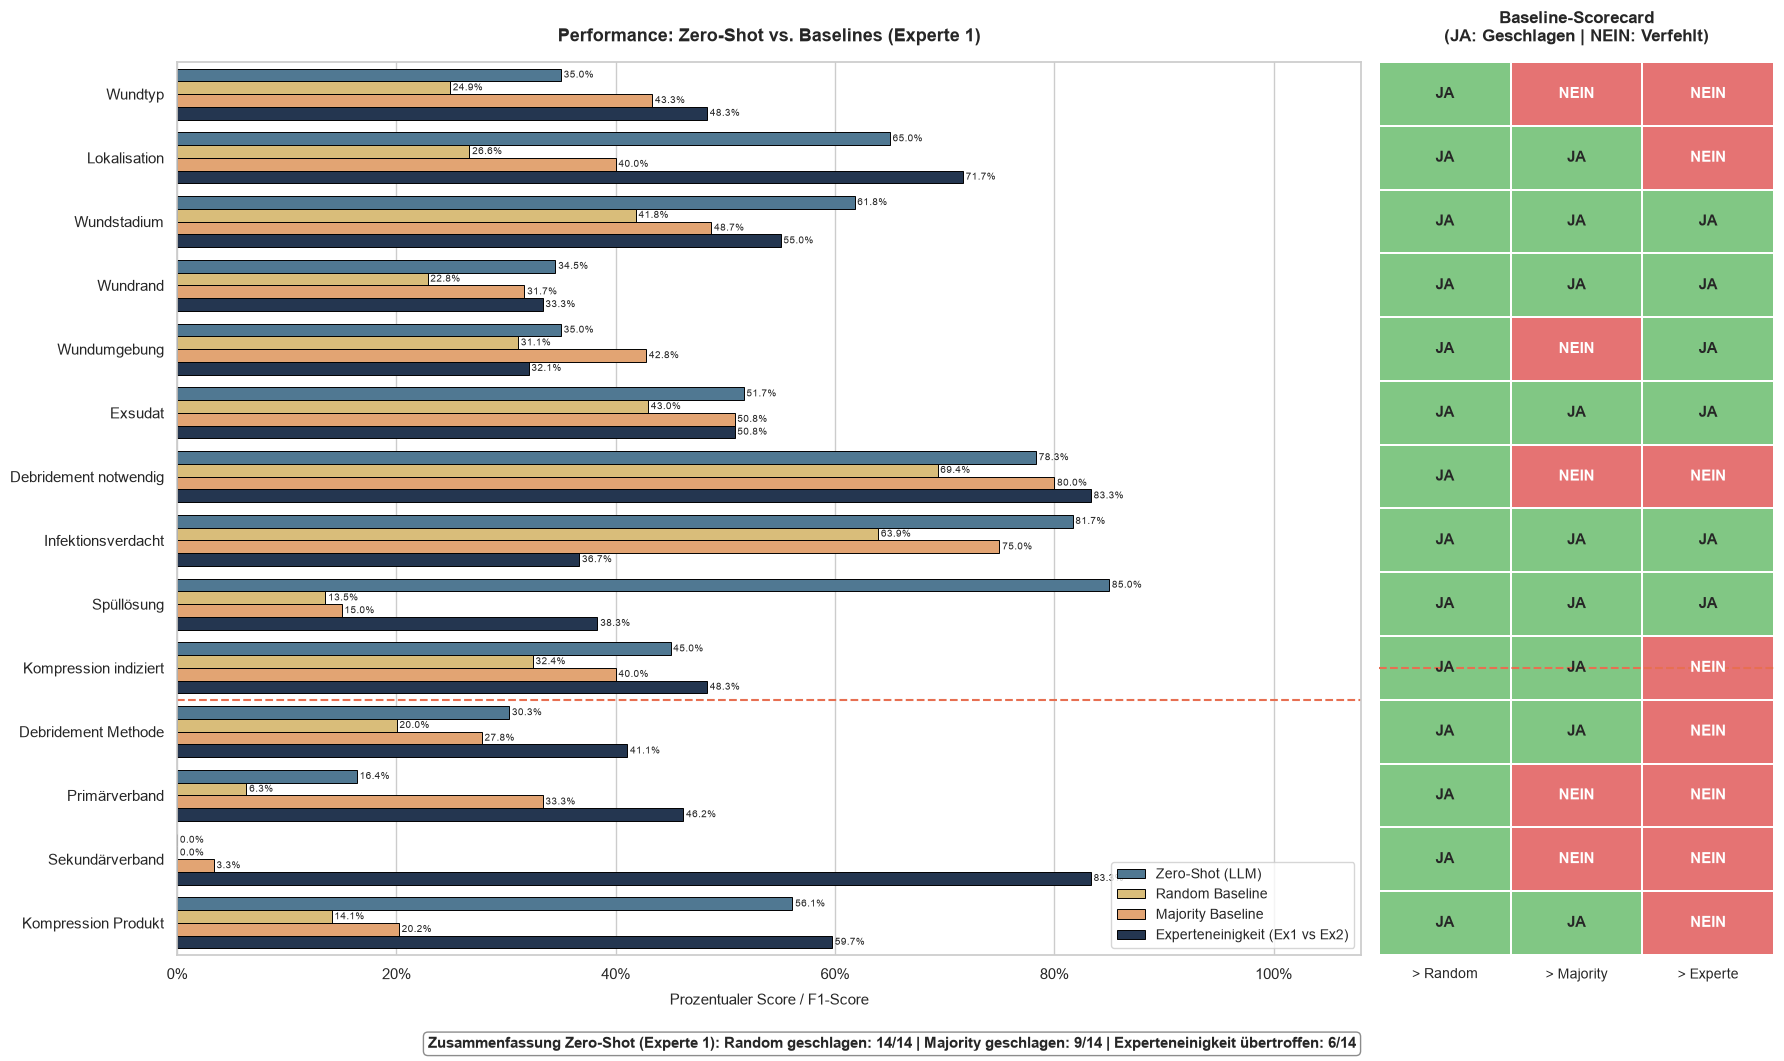

In [23]:
# Plot 1: Zero-Shot vs. Baselines & Experteneinigkeit (Bezug: Experte 1)
pa.plot_zero_shot_exp1()

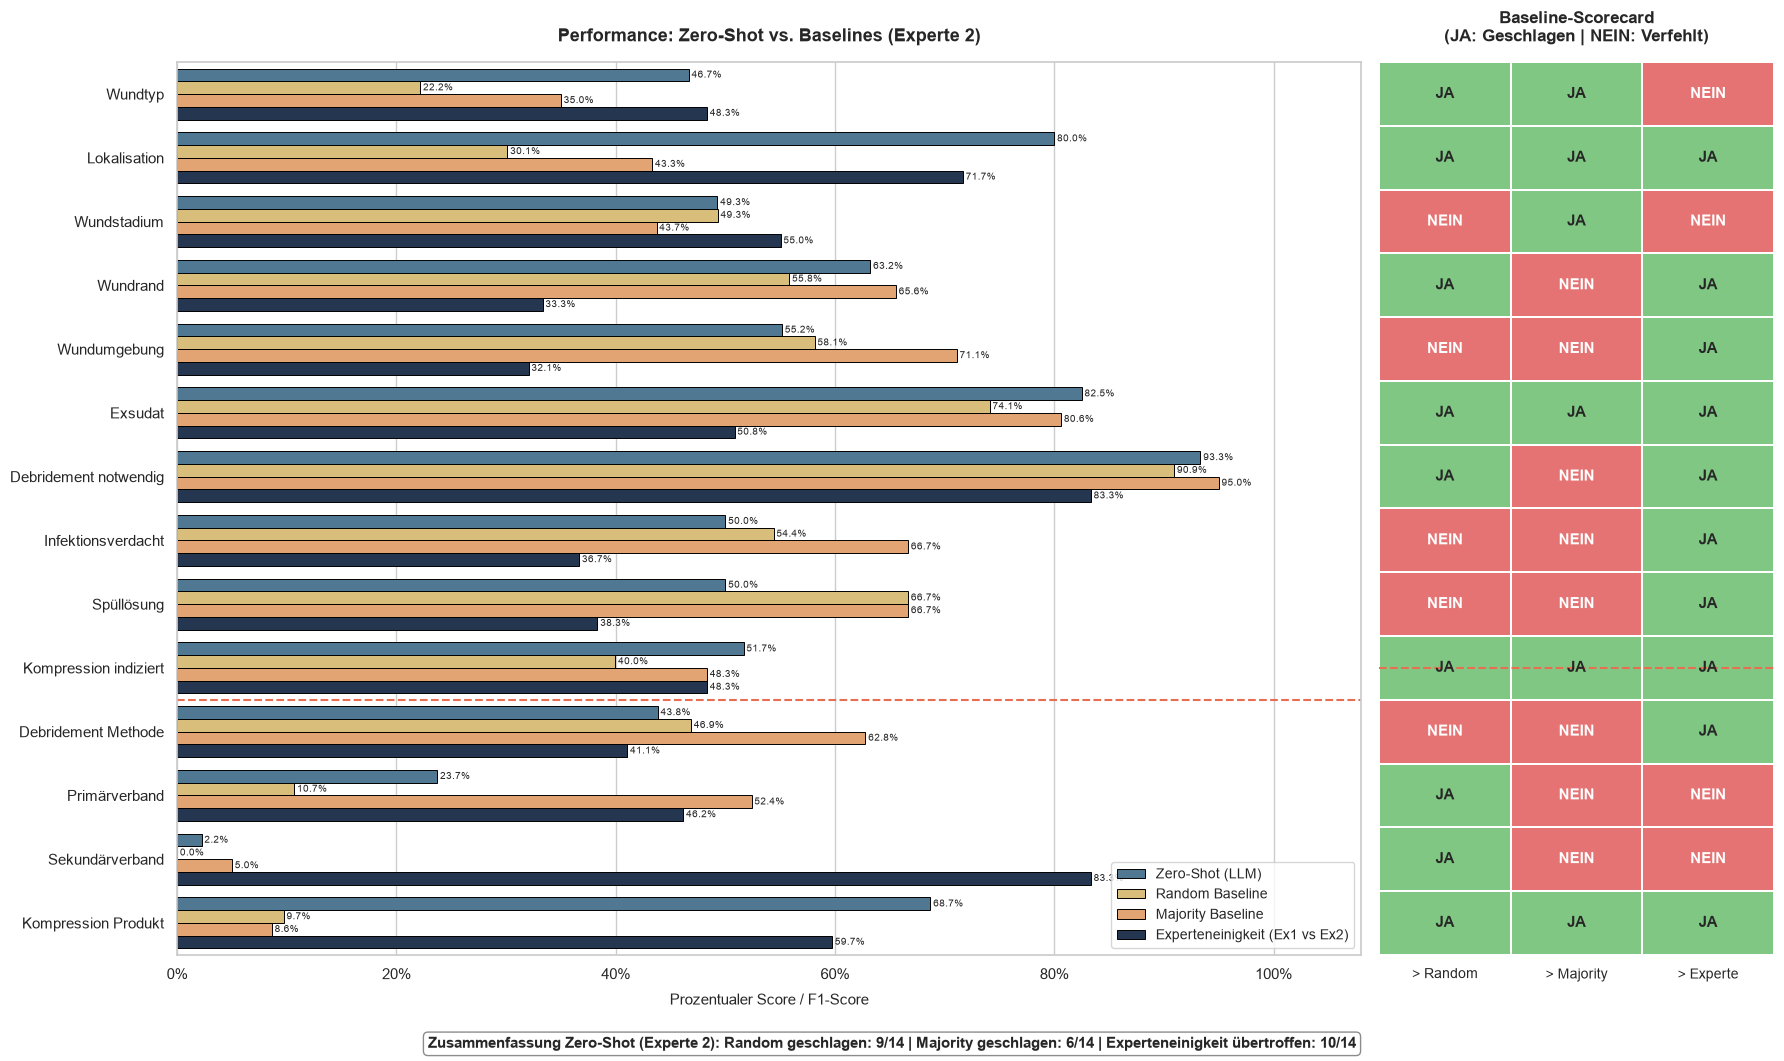

In [24]:
# Plot 2: Zero-Shot vs. Baselines & Experteneinigkeit (Bezug: Experte 2)
pa.plot_zero_shot_exp2()

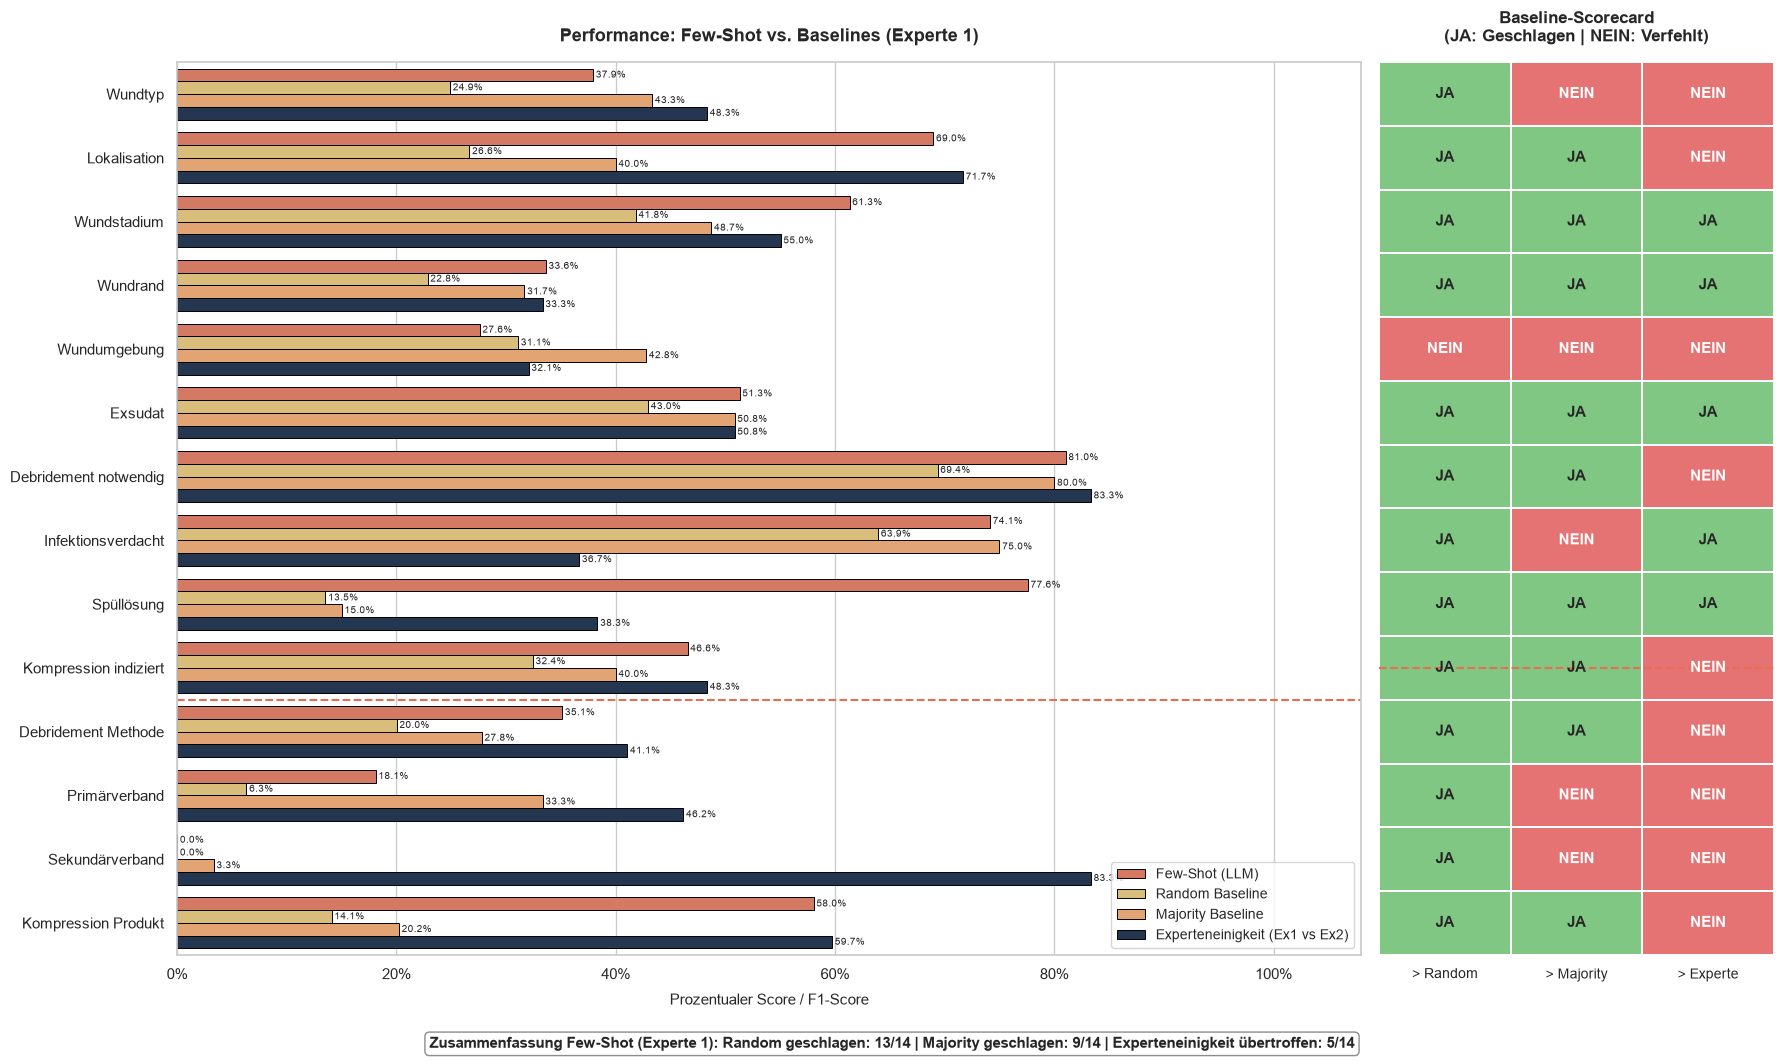

In [25]:
# Plot 3: Few-Shot vs. Baselines & Experteneinigkeit (Bezug: Experte 1)
pa.plot_few_shot_exp1()

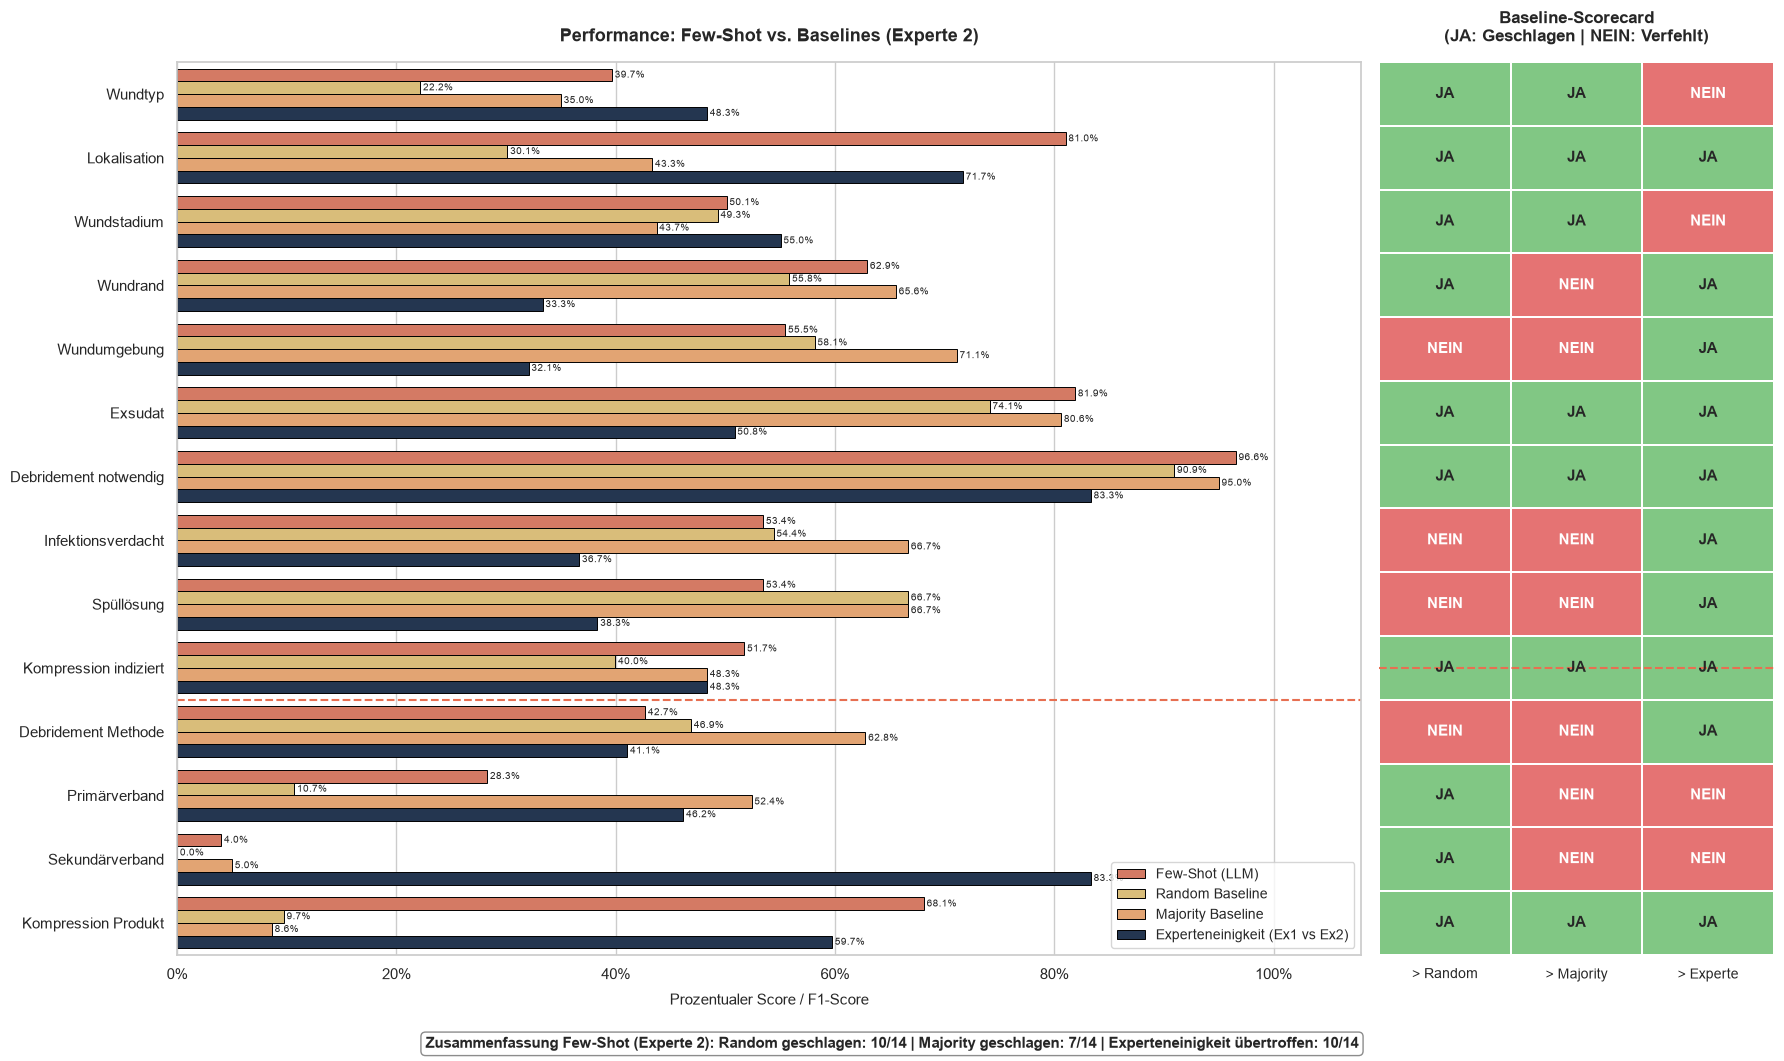

In [26]:
# Plot 4: Few-Shot vs. Baselines & Experteneinigkeit (Bezug: Experte 2)
pa.plot_few_shot_exp2()

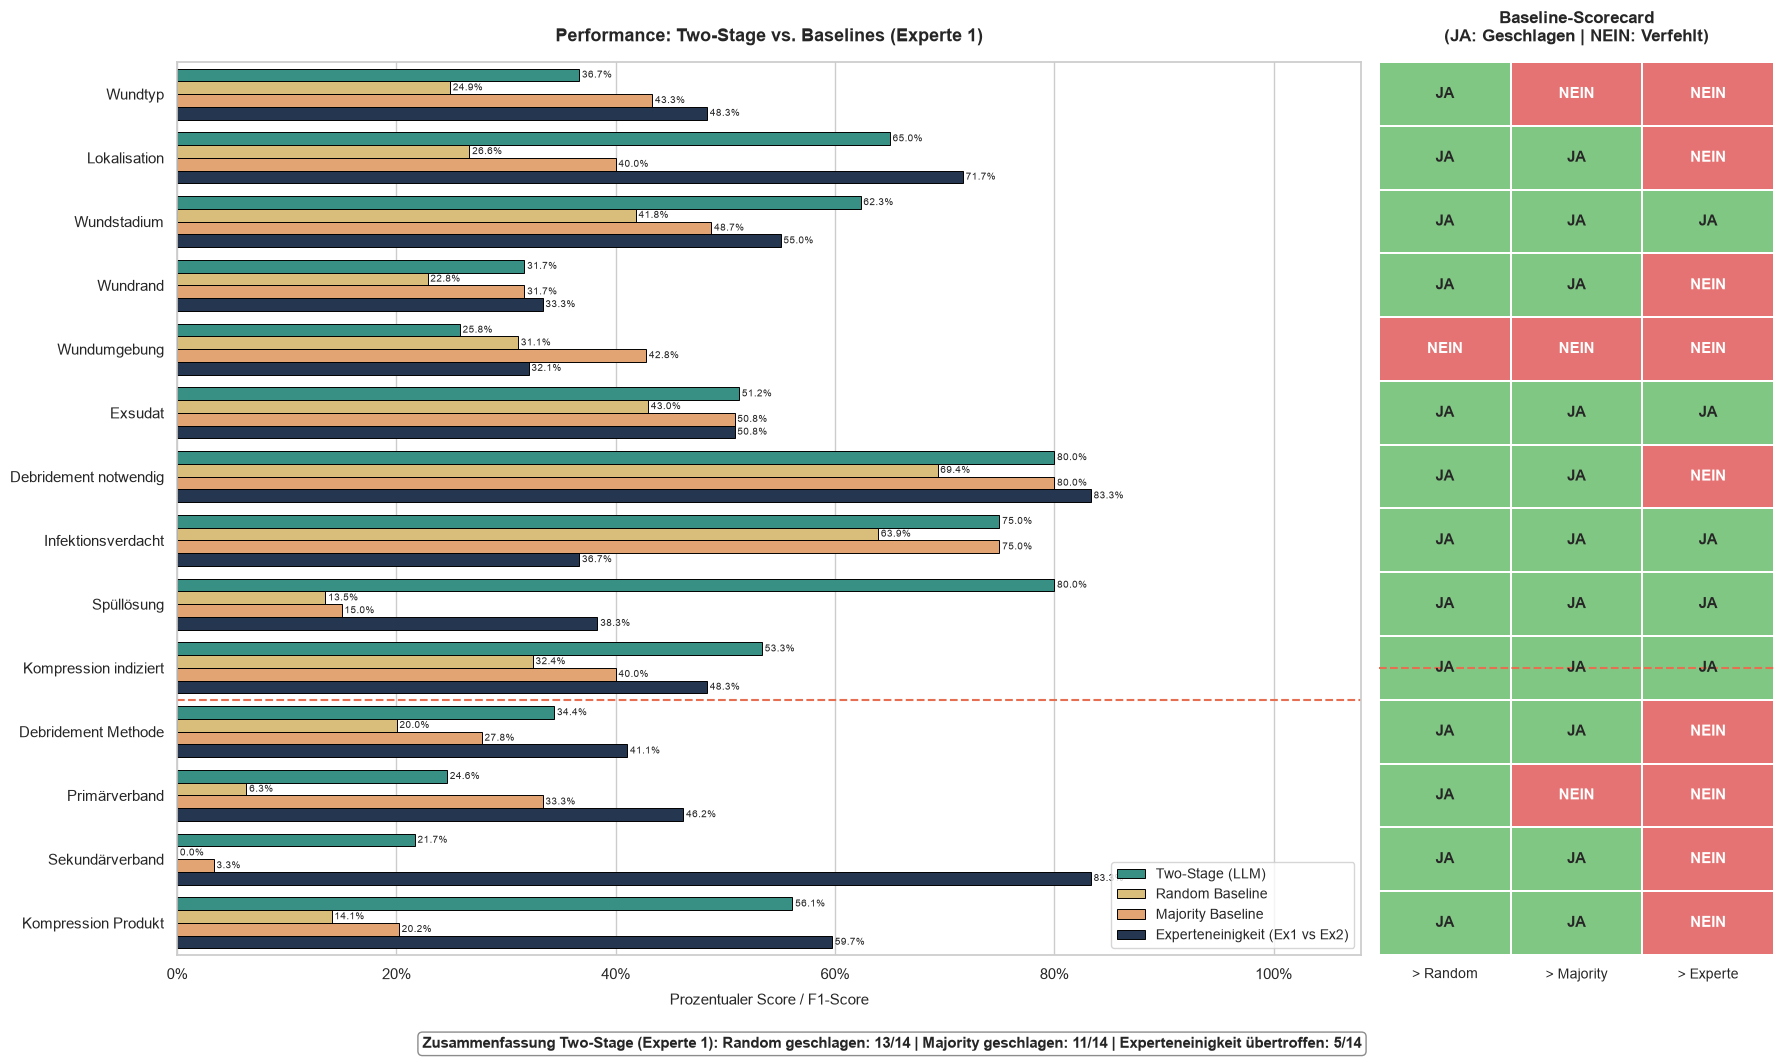

In [27]:
# Plot 5: Two-Stage vs. Baselines & Experteneinigkeit (Bezug: Experte 1)
pa.plot_two_stage_exp1()

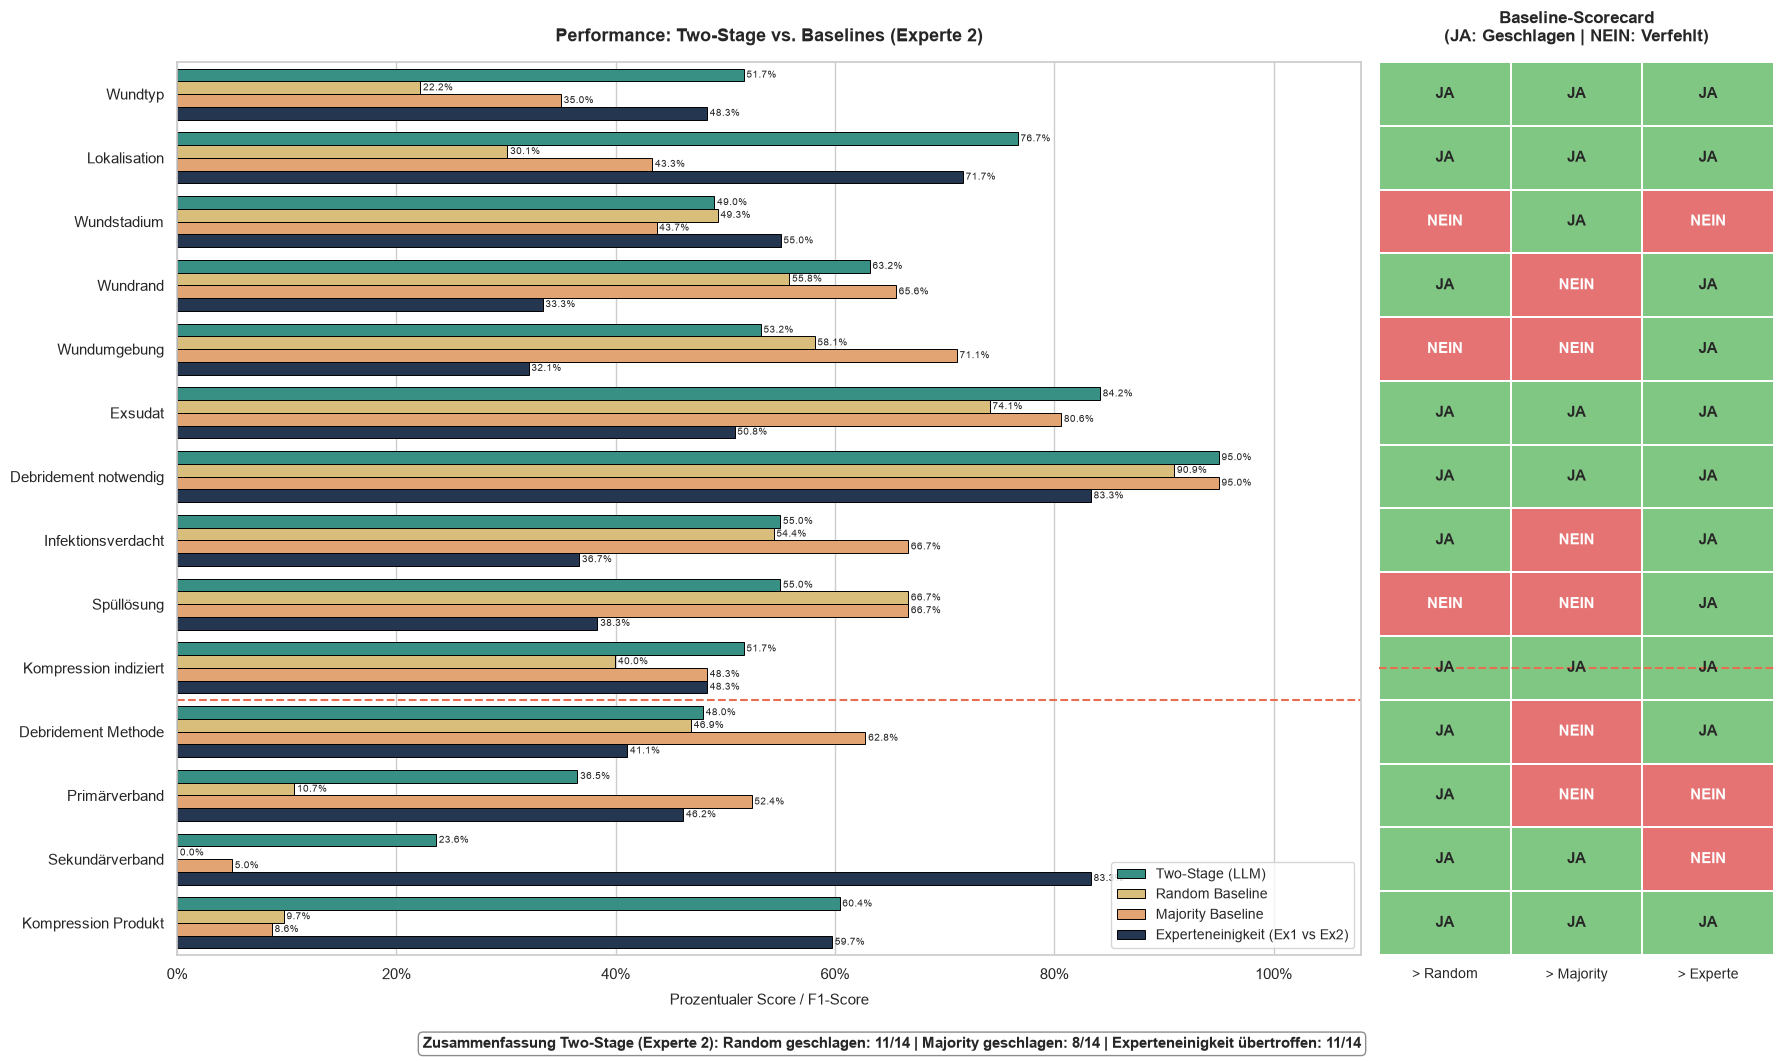

In [28]:
# Plot 6: Two-Stage vs. Baselines & Experteneinigkeit (Bezug: Experte 2)
pa.plot_two_stage_exp2()

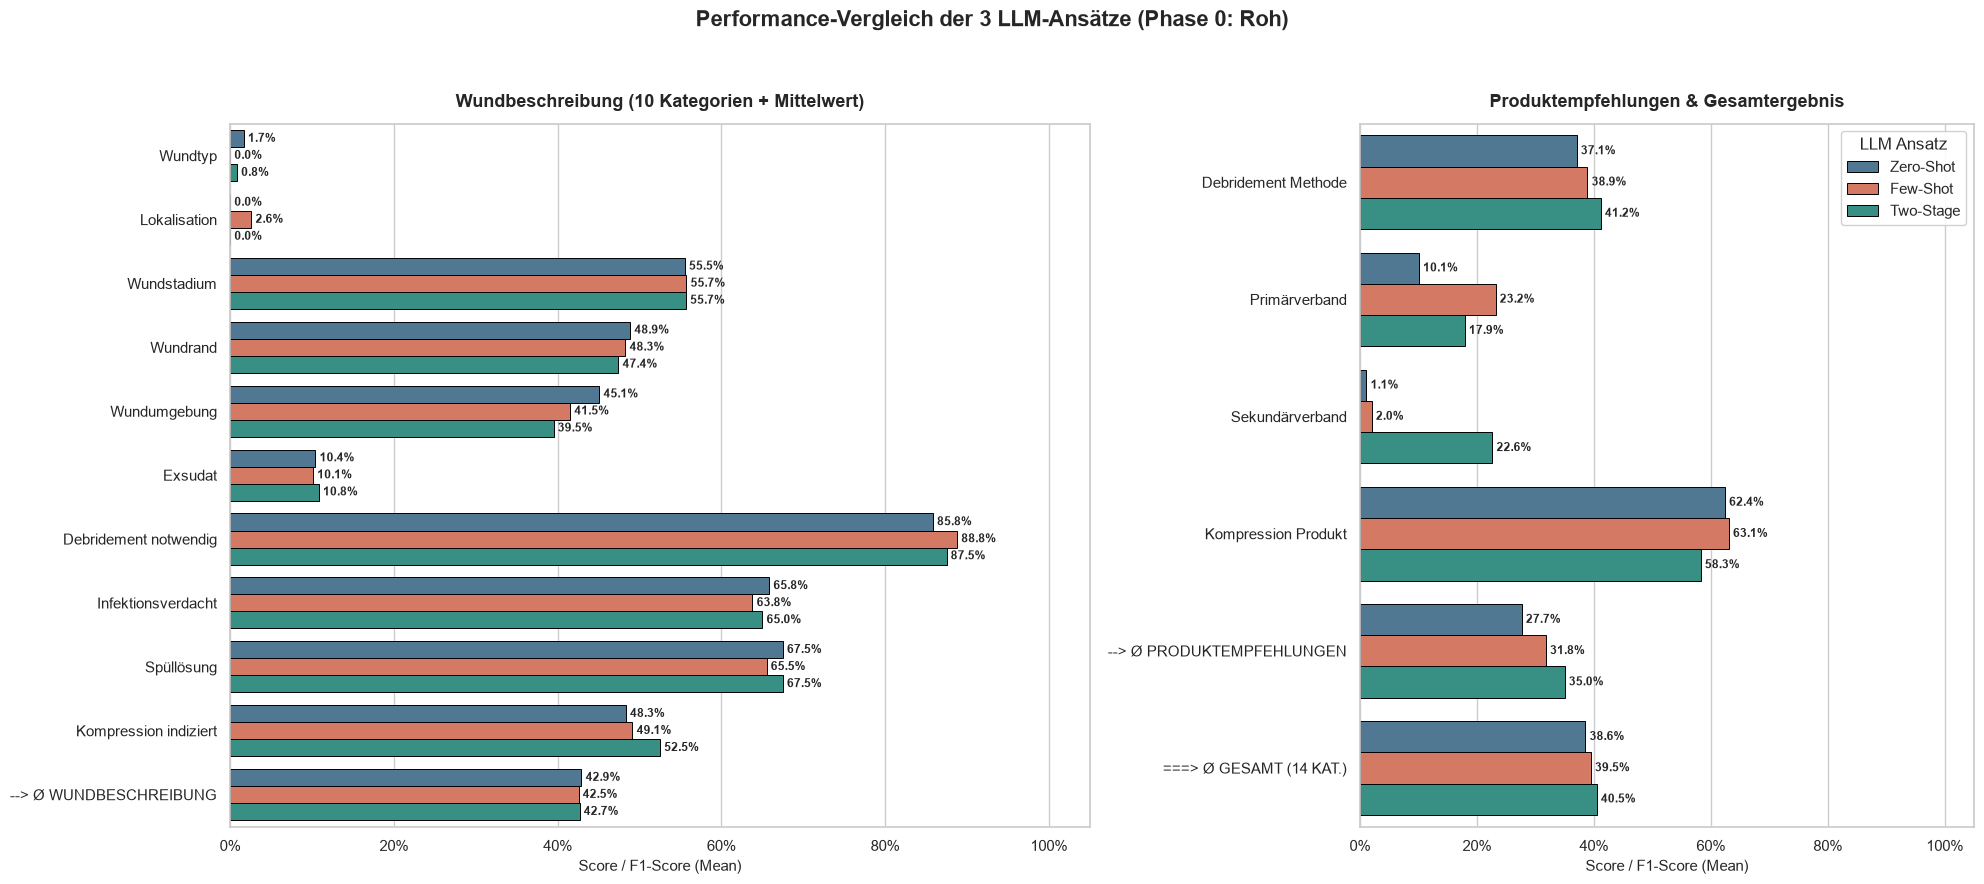

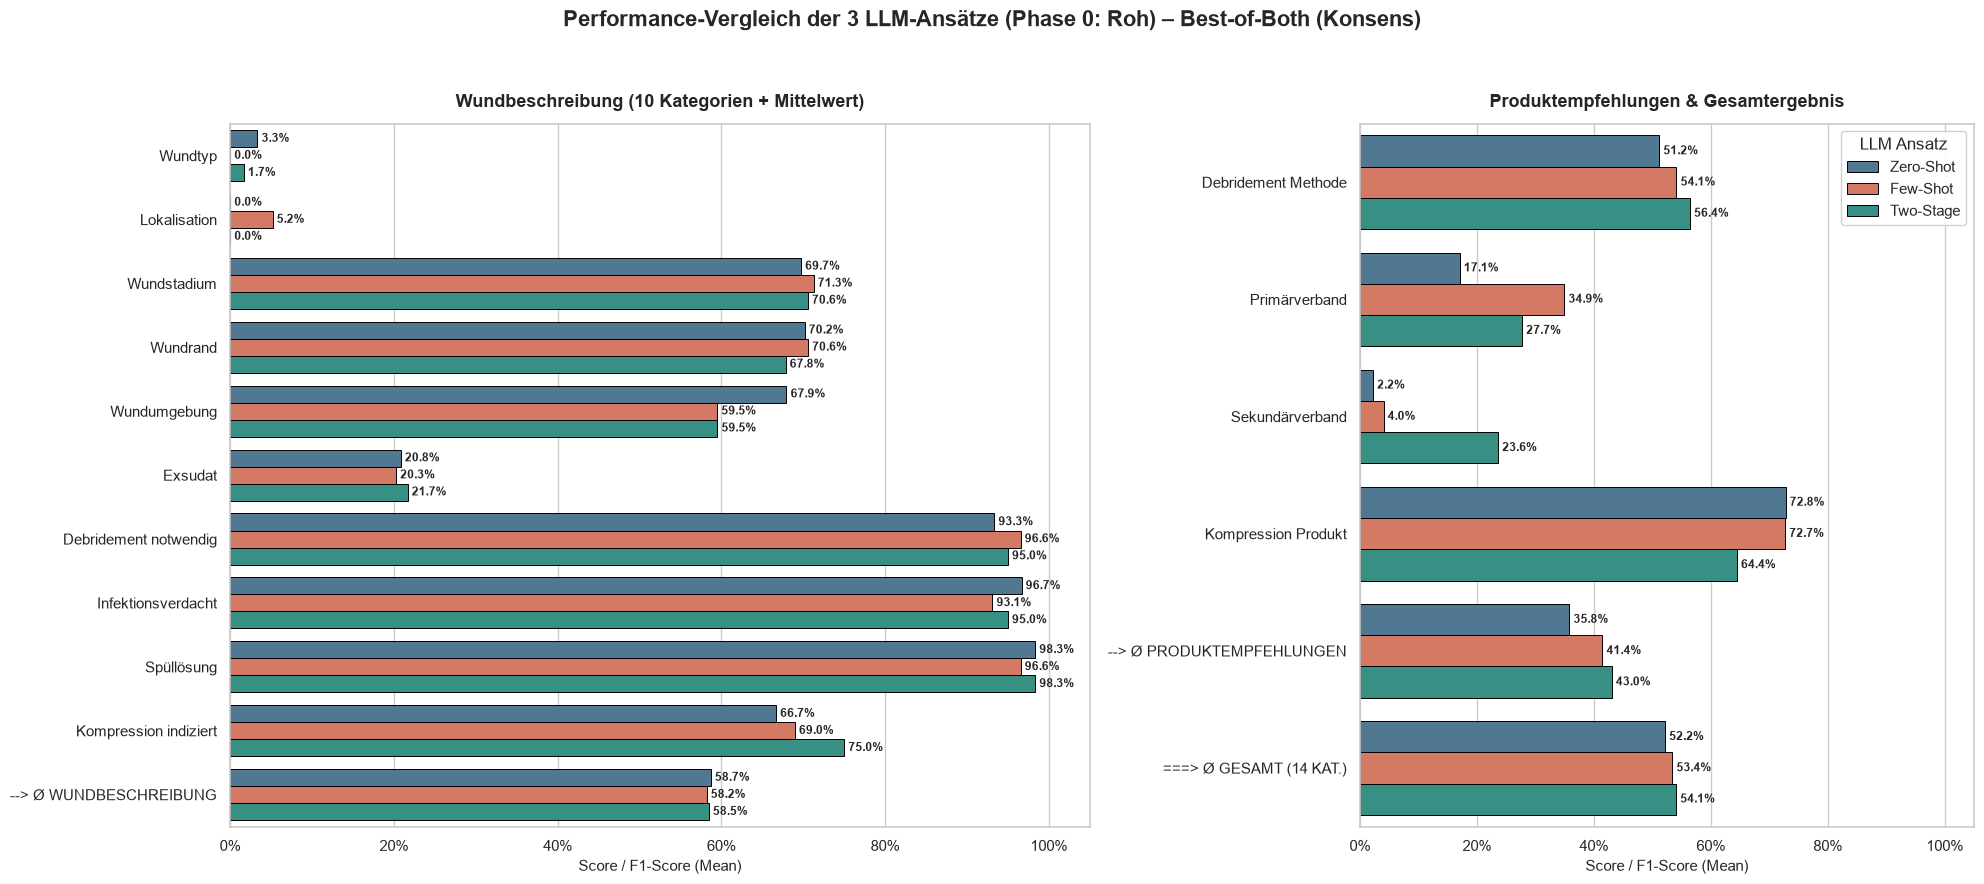

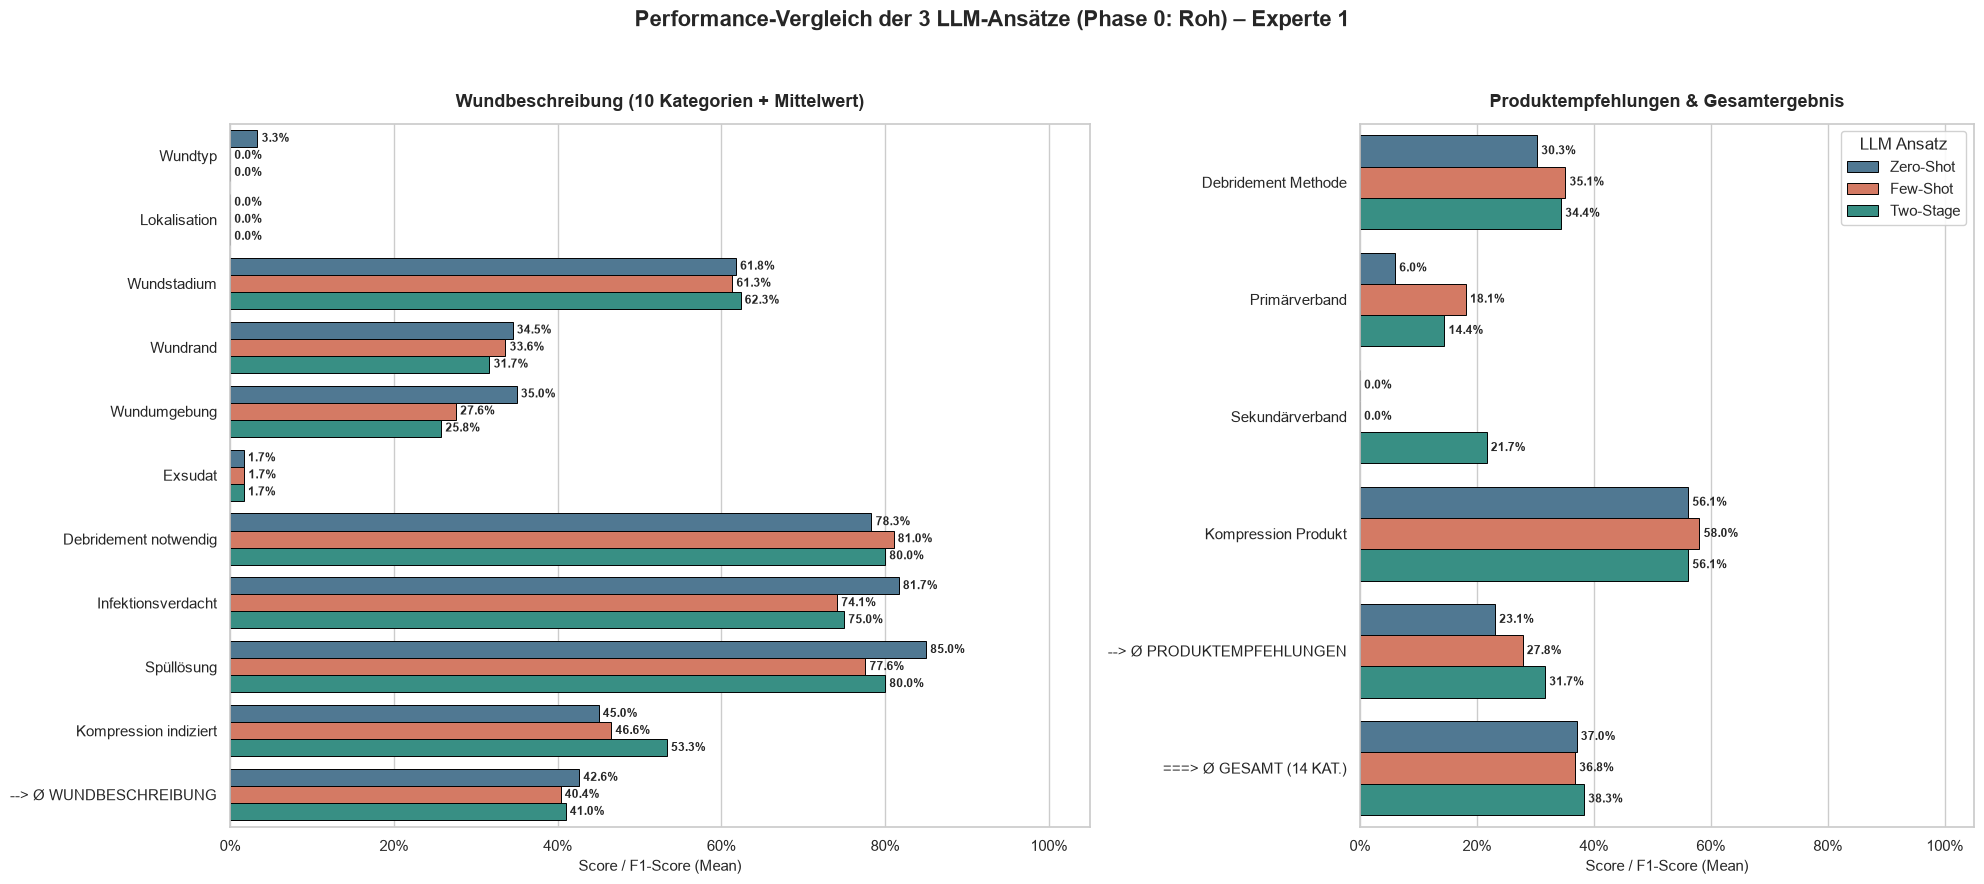

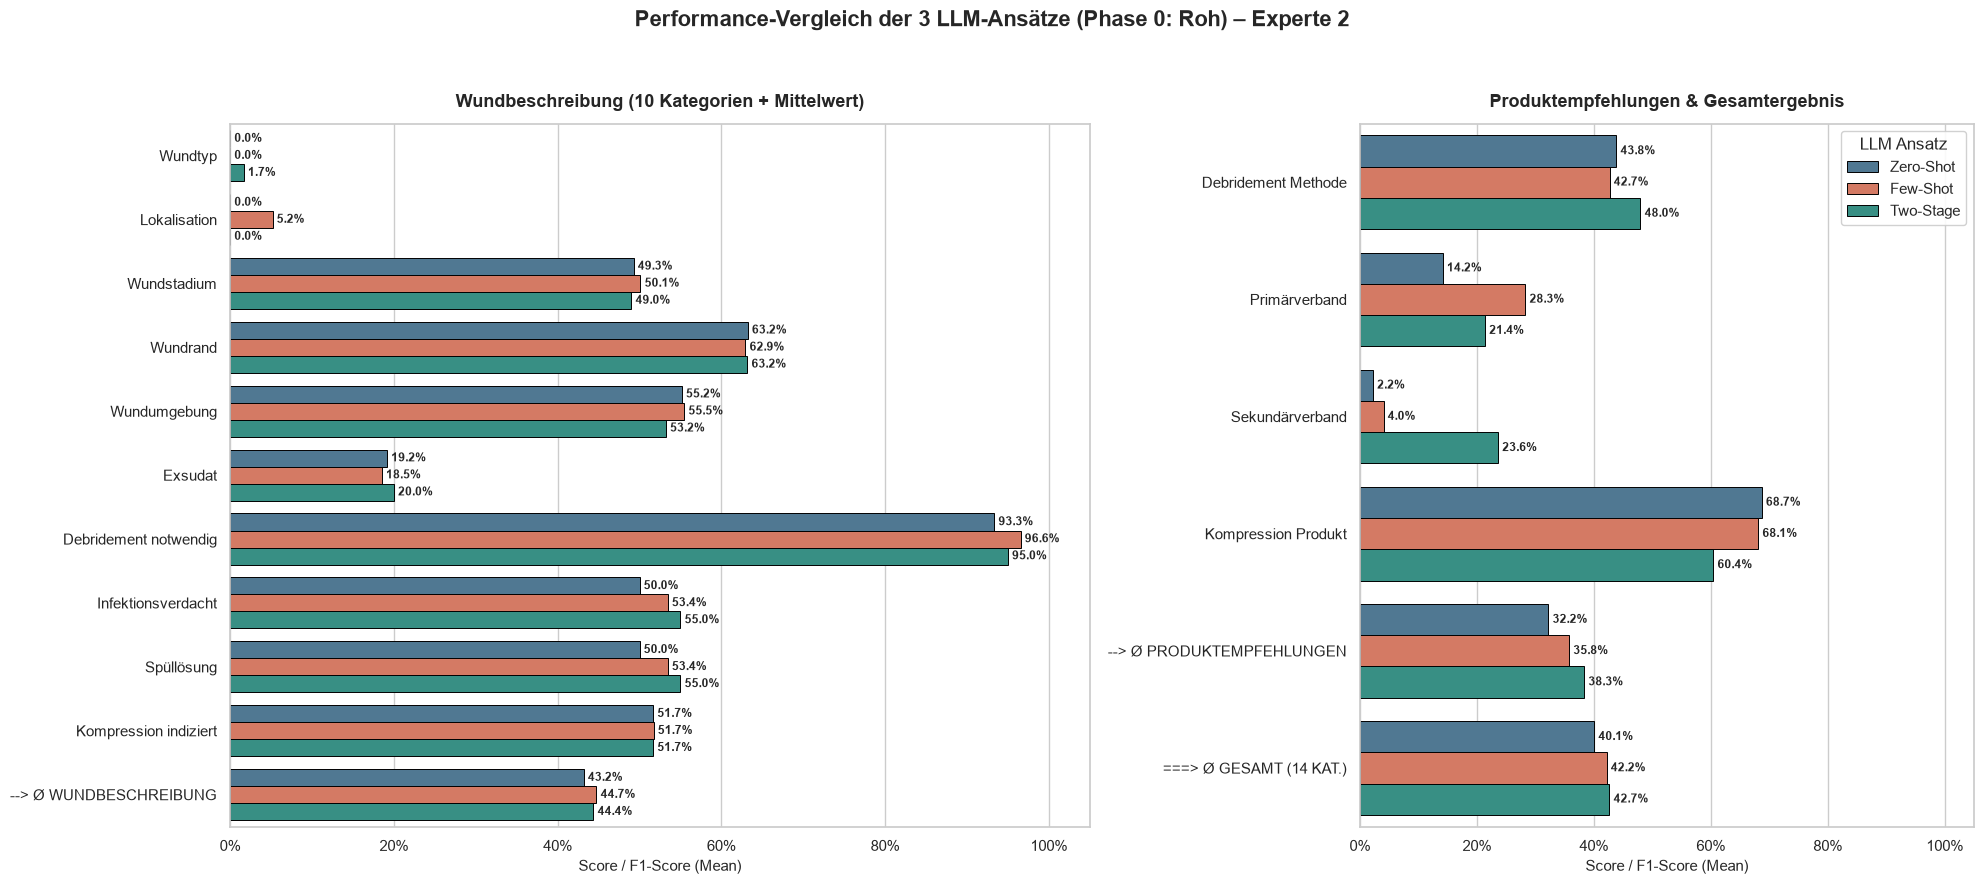

In [29]:
from prompt_analysis import PromptAnalysis

# Objekt für Rohdaten initialisieren
pa_raw = PromptAnalysis(normalised=False)

# --- 1. Experten-Durchschnitt (Roh) ---
pa_raw.plot_overview_groups()

# --- 2. Best-of-Both / Konsens (Roh) ---
pa_raw.plot_overview_groups_consensus()

# --- 3. Experte 1 getrennt (Roh) ---
pa_raw.plot_overview_groups_expert(1)

# --- 4. Experte 2 getrennt (Roh) ---
pa_raw.plot_overview_groups_expert(2)

/Users/mertakdemir/Developer/uni/Modell/notebooks/analyse_prompts/prompt_analysis.py:503: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/mertakdemir/Developer/uni/Modell/notebooks/analyse_prompts/prompt_analysis.py:545: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


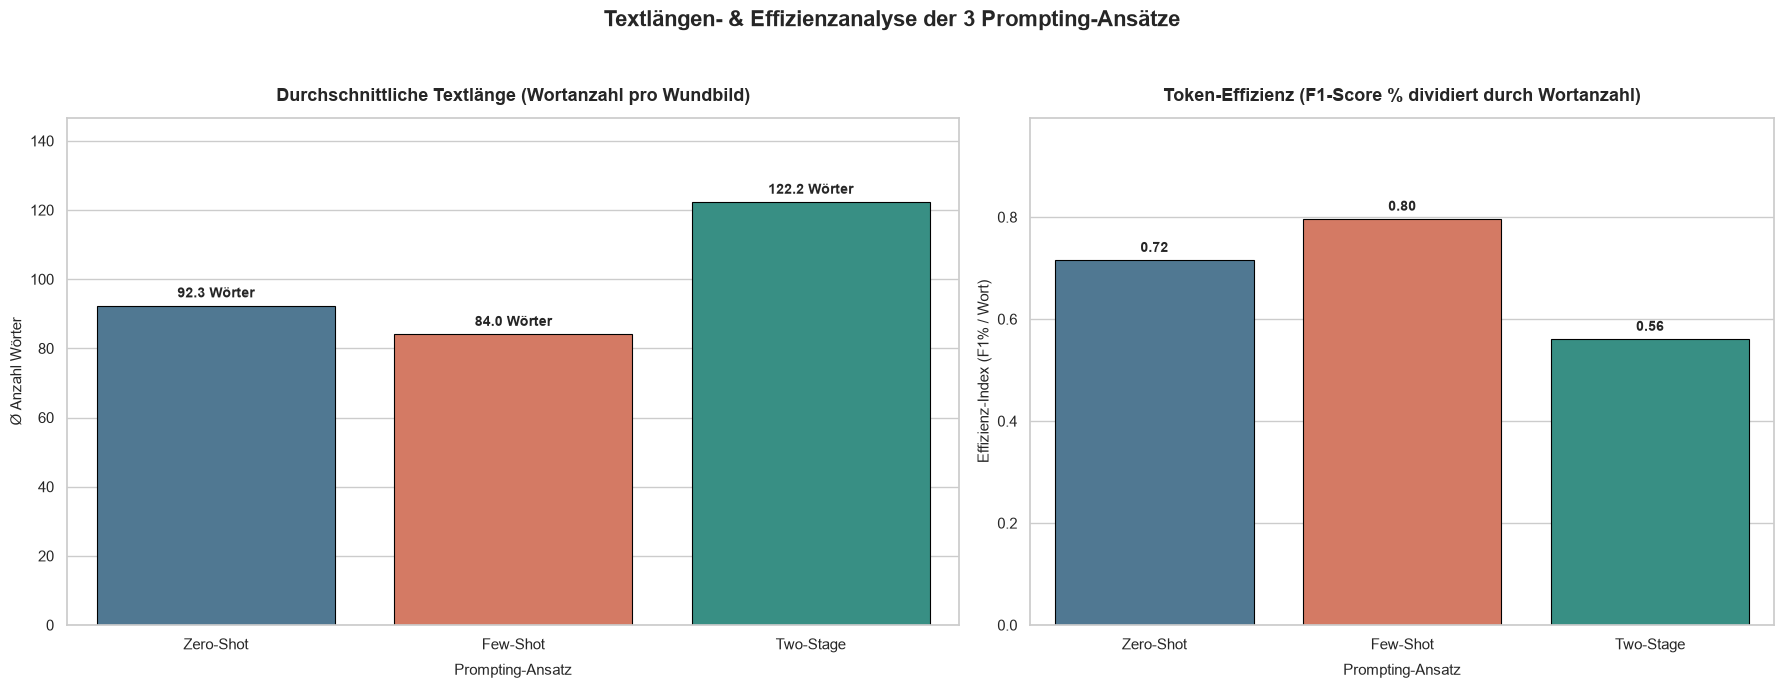

In [30]:
# Textlängen- & Effizienzanalyse (Wortanzahl vs. F1-Score)
pa.plot_word_count_analysis()